In [10]:
import transformer_lens as tl
from transformer_lens import HookedTransformer, HookedTransformerConfig
import torch
import pandas as pd
import numpy as np

In [11]:
device = 'cuda:0'

In [12]:
from datasets import load_dataset
model: HookedTransformer = tl.HookedTransformer.from_pretrained("pythia-14m",device=device)
num_model_blocks = len(model.blocks)
# Entries 0..num_model_blocks-1 are block probes; the last entry is the final output head.
unembedding_matrices = torch.nn.ModuleList([
    torch.nn.Linear(model.cfg.d_model, model.cfg.d_vocab, bias=True).to(device)
    for _ in range(num_model_blocks)
])
final_unembedding = unembedding_matrices[-1]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 16351.22it/s]


Loaded pretrained model pythia-14m into HookedTransformer


In [13]:
batch_size = 50
context_window = 10
num_text_samples = 1000
num_batches = num_text_samples // batch_size

### Load and clean pile-10k dataset, initialize data loader

In [14]:
ds = load_dataset("NeelNanda/pile-10k")
cleaned_text = ds['train']['text'][0]
tokens = torch.zeros(1, context_window+1).to(device)
torch.manual_seed(0)
rng = np.random.default_rng(seed=0)
randoms = torch.from_numpy(rng.choice(len(ds['train']), size=num_text_samples, replace=False)).to(device)
for i in range(num_text_samples):
    texty_text = ds['train']['text'][randoms[i].item()]
    encoded = model.tokenizer.encode(texty_text)
    if len(encoded) < context_window+1:
        continue
    tokens_add = torch.tensor(encoded).unfold(0, context_window+1, 1).to(device)
    tokens = torch.cat((tokens, tokens_add), dim=0)
tokens = tokens[1:].long()
data_loader = torch.utils.data.DataLoader(tokens, batch_size=batch_size, shuffle=True)


In [15]:
from datetime import datetime
from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
save_base_model_state = False

def save_training_results(run_name, training_history=None, extra=None, save_base_model_state=False):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = results_dir / f"{run_name}_{timestamp}.pt"
    payload = {
        "run_name": run_name,
        "model_name": getattr(model.cfg, "model_name", None),
        "num_model_blocks": num_model_blocks,
        "context_window": context_window,
        "num_text_samples": num_text_samples,
        "batch_size": batch_size,
        "num_epochs": num_epochs,
        "unembedding_matrices_state_dict": {
            key: value.detach().cpu()
            for key, value in unembedding_matrices.state_dict().items()
        },
        "training_history": training_history or [],
    }
    if extra is not None:
        payload.update(extra)
    if save_base_model_state:
        payload["model_state_dict"] = {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        }
    torch.save(payload, save_path)
    print(f"Saved training results to {save_path}")
    return save_path

num_epochs =1
criterion = torch.nn.CrossEntropyLoss()
print(criterion(torch.tensor([[0.1, 0.2, 0.3], [0, 0, 0]]), torch.tensor([2, 1])))
optimizer_list = [torch.optim.Adam(head.parameters(), lr=1e-3) for head in unembedding_matrices]

tensor(1.0503)


In [16]:
# Freeze the base model; only train the probe heads and final output head in this loop.
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
unembedding_matrices.train()
probe_training_history = []

for epoch in range(num_epochs):
    iteration = 0
    for batch in data_loader:
        # print(batch)
        with torch.no_grad():
            _, cache = model.run_with_cache(batch[:, :-1])
        targets = batch[:, 1:]
        block_loss_values = []
        for i in range(num_model_blocks):
            optimizer_list[i].zero_grad()
            # CHANGED: detach to avoid backprop into the model when training only unembedding matrices
            block_output = cache["resid_post", i]
            # Train without applying the final layer norm.
            output = unembedding_matrices[i](block_output)
            # CHANGED: CrossEntropyLoss expects class indices, not one-hot targets
            loss = criterion(output.reshape(-1, output.shape[-1]), targets.reshape(-1))
            loss.backward()
            optimizer_list[i].step()
            block_loss_values.append(loss.item())
        probe_training_history.append({
            "epoch": epoch,
            "iteration": iteration,
            "block_losses": block_loss_values,
        })

        if iteration % 100 == 0:
            print(
                f"Epoch {epoch}, Iteration {iteration}, "
            )
        iteration += 1




Epoch 0, Iteration 0, 
Epoch 0, Iteration 100, 
Epoch 0, Iteration 200, 
Epoch 0, Iteration 300, 
Epoch 0, Iteration 400, 
Epoch 0, Iteration 500, 
Epoch 0, Iteration 600, 
Epoch 0, Iteration 700, 


KeyboardInterrupt: 

In [19]:
probe_results_path = save_training_results(
    "probe_heads",
    training_history=probe_training_history,
    extra={"probe_input_normalization": "raw_resid_post"},
    save_base_model_state=False,
)

Saved training results to results/probe_heads_20260508_235051.pt


Saved distance results to results/distance_to_final_20260508_235031.pt
Saved distance plot to results/distance_to_final_20260508_235031.png


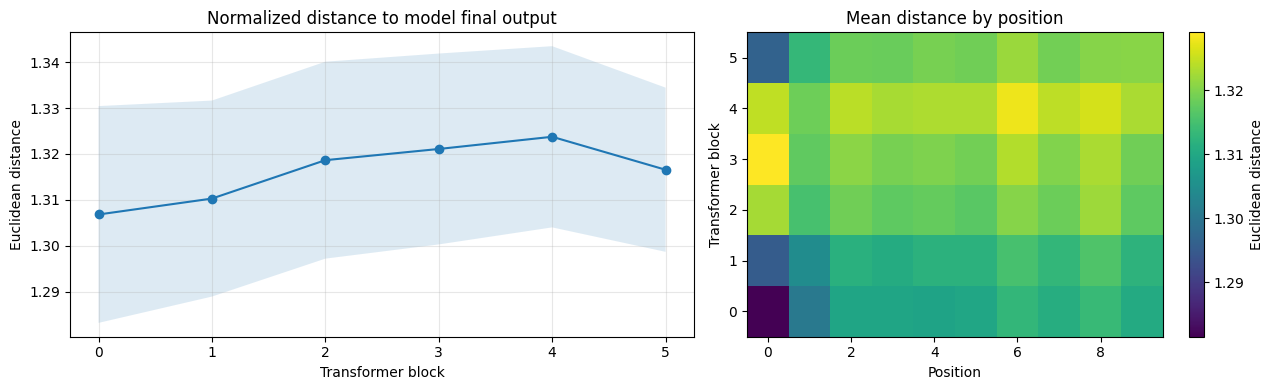

In [17]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

distance_sample_size = min(64, tokens.shape[0])
distance_generator = torch.Generator(device="cpu").manual_seed(0)
sample_idx = torch.randperm(tokens.shape[0], generator=distance_generator)[:distance_sample_size]
sample_inputs = tokens[sample_idx.to(tokens.device), :-1]

# Match the first training loop above: block heads were trained on raw resid_post.
# Set this to True if you instead trained the heads using model.ln_final(resid_post).
apply_ln_to_probe_inputs = False

with torch.no_grad():
    _, sample_cache = model.run_with_cache(sample_inputs)
    final_resid = sample_cache["resid_post", num_model_blocks - 1]
    true_final_vectors = model.unembed(model.ln_final(final_resid))
    true_final_vectors = F.normalize(true_final_vectors, p=2, dim=-1, eps=1e-12)

    block_distance_by_pos = []
    for layer in range(num_model_blocks):
        block_resid = sample_cache["resid_post", layer]
        if apply_ln_to_probe_inputs:
            block_resid = model.ln_final(block_resid)

        mapped_vectors = unembedding_matrices[layer](block_resid)
        mapped_vectors = F.normalize(mapped_vectors, p=2, dim=-1, eps=1e-12)
        distances = torch.linalg.vector_norm(mapped_vectors - true_final_vectors, dim=-1)
        block_distance_by_pos.append(distances.detach().cpu())

block_distance_by_pos = torch.stack(block_distance_by_pos)
mean_distance = block_distance_by_pos.mean(dim=(1, 2)).numpy()
std_distance = block_distance_by_pos.std(dim=(1, 2)).numpy()
position_mean_distance = block_distance_by_pos.mean(dim=1).numpy()
layers = np.arange(num_model_blocks)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.2, 1]})
axes[0].plot(layers, mean_distance, marker="o")
axes[0].fill_between(layers, mean_distance - std_distance, mean_distance + std_distance, alpha=0.15)
axes[0].set_title("Normalized distance to model final output")
axes[0].set_xlabel("Transformer block")
axes[0].set_ylabel("Euclidean distance")
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(position_mean_distance, aspect="auto", origin="lower")
axes[1].set_title("Mean distance by position")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Transformer block")
fig.colorbar(im, ax=axes[1], label="Euclidean distance")
plt.tight_layout()

distance_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
distance_results_path = results_dir / f"distance_to_final_{distance_timestamp}.pt"
distance_plot_path = results_dir / f"distance_to_final_{distance_timestamp}.png"
torch.save({
    "sample_idx": sample_idx.cpu(),
    "apply_ln_to_probe_inputs": apply_ln_to_probe_inputs,
    "block_distance_by_pos": block_distance_by_pos,
    "mean_distance": torch.from_numpy(mean_distance),
    "std_distance": torch.from_numpy(std_distance),
    "position_mean_distance": torch.from_numpy(position_mean_distance),
}, distance_results_path)
fig.savefig(distance_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved distance results to {distance_results_path}")
print(f"Saved distance plot to {distance_plot_path}")
plt.show()